# PCA + K-Means - Segmentacion de empleados

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Reducción de Dimensionalidad · PCA

---

**Objetivo:** Combinar PCA y K-Means en un pipeline: primero reducir la dimensionalidad de 5 metricas de rendimiento, despues segmentar a los empleados en el espacio reducido.

**Contexto de negocio:** Una empresa con 232 empleados de ventas quiere identificar perfiles de rendimiento (top performers, promedio, bajo rendimiento) para asignar formacion personalizada. Pero las 5 metricas estan correlacionadas — PCA las sintetiza antes de agrupar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

sns.set_style("whitegrid")

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para IDENTIDAD DE CLUSTER — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes. En scatter con 4+ clusters el color solo no es 100% seguro para
# daltonismo severo, por eso cada cluster lleva también una forma de marcador distinta.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 1. Carga y exploracion del dataset

In [2]:
ruta = os.path.join(os.path.dirname(os.path.abspath("__file__")), "employees.xlsx")
df = pd.read_excel(ruta)
print(f"Dataset: {df.shape[0]} registros, {df.shape[1]} variables")
print(f"Columnas: {list(df.columns)}")
display(df.describe())

Dataset: 232 registros, 6 variables
Columnas: ['idempleado', 'Sales_€K', 'Customers', 'Training_Hours', 'Satisfaction', 'Calls_per_day']


,idempleado,Sales_€K,Customers,Training_Hours,Satisfaction,Calls_per_day
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000
mean,116.500000,75.155172,34.448276,10.021552,93.495690,25.637931
std,67.116814,15.017798,7.502201,2.988356,9.744795,8.455021
min,1.000000,39.000000,15.000000,2.000000,65.000000,0.000000
25%,58.750000,66.000000,29.000000,8.000000,88.000000,26.000000
50%,116.500000,75.000000,34.500000,10.000000,100.000000,30.000000
75%,174.250000,85.000000,39.250000,12.000000,100.000000,30.000000
max,232.000000,112.000000,56.000000,20.000000,100.000000,30.000000


## 2. Preparacion de datos

In [3]:
# Excluir ID si existe
id_cols = [c for c in df.columns if "id" in c.lower()]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_cols]
print(f"Variables de rendimiento: {num_cols}")

X = df[num_cols].dropna()
print(f"Registros validos: {len(X)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos estandarizados")

Variables de rendimiento: ['Sales_€K', 'Customers', 'Training_Hours', 'Satisfaction', 'Calls_per_day']
Registros validos: 232
Datos estandarizados


## 3. Matriz de correlacion

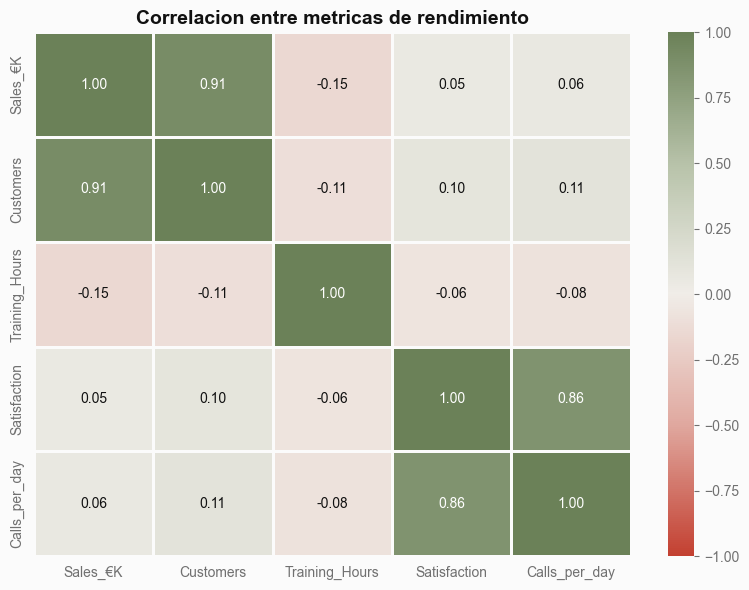

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_scaled, columns=num_cols).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0,
            vmin=-1, vmax=1, linewidths=2, linecolor=BACKGROUND, ax=ax)
color_annotations(ax, corr.values, threshold=0.8)
ax.set_title("Correlacion entre metricas de rendimiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. PCA

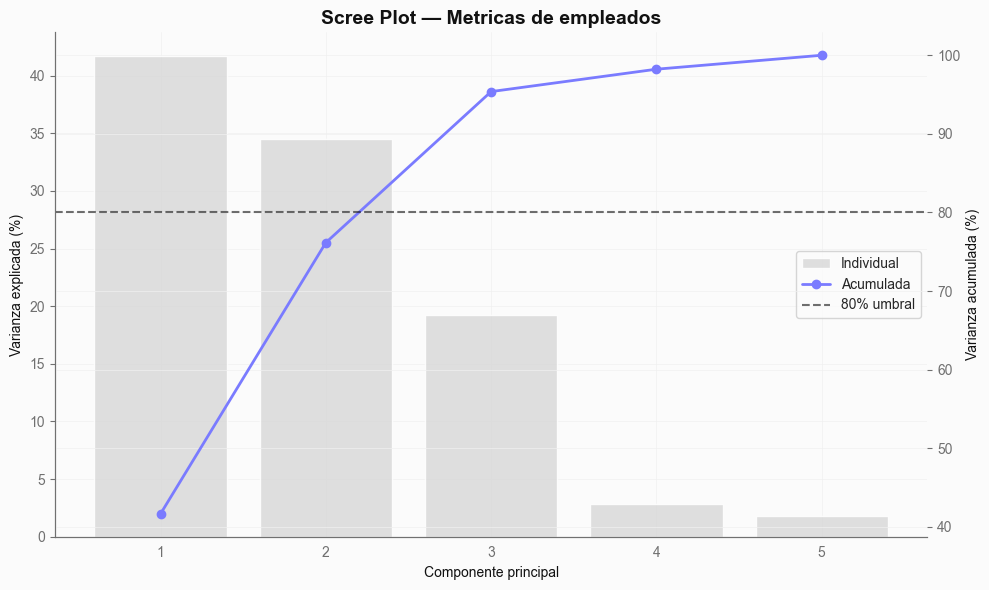

Componentes para >= 80% varianza: 3
Varianza acumulada con 3 PC: 95.4%


In [5]:
pca = PCA(random_state=42)
X_pca_full = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(var_exp)+1), var_exp * 100, alpha=0.85, color=NEUTRAL_BAR, label="Individual")
ax2 = ax1.twinx()
ax2.plot(range(1, len(var_exp)+1), var_cum * 100, marker="o", color=PURPLE,
         linewidth=2, label="Acumulada")
ax2.axhline(y=80, color=INK, linestyle="--", alpha=0.6, label="80% umbral")

ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada (%)")
ax2.set_ylabel("Varianza acumulada (%)")
ax1.set_title("Scree Plot — Metricas de empleados", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

n_comp = np.argmax(var_cum >= 0.80) + 1
print(f"Componentes para >= 80% varianza: {n_comp}")
print(f"Varianza acumulada con {n_comp} PC: {var_cum[n_comp-1]*100:.1f}%")

## 5. Matriz de cargas

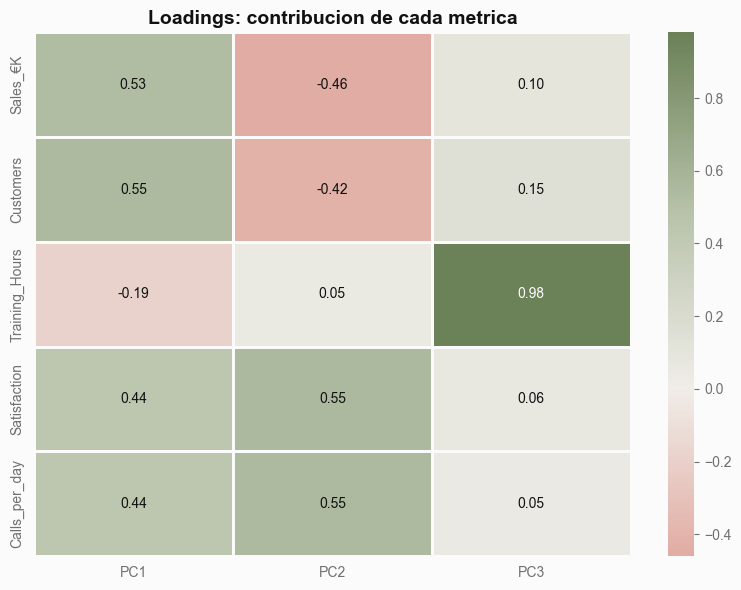

PC1: dominada por Customers (0.55), Sales_€K (0.53)
PC2: dominada por Satisfaction (0.55), Calls_per_day (0.55)
PC3: dominada por Training_Hours (0.98), Customers (0.15)


In [6]:
loadings = pd.DataFrame(
    pca.components_[:n_comp].T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(n_comp)]
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0,
            linewidths=2, linecolor=BACKGROUND, ax=ax)
color_annotations(ax, loadings.values, threshold=0.8)
ax.set_title("Loadings: contribucion de cada metrica", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False)
    print(f"{pc}: dominada por {top.index[0]} ({top.iloc[0]:.2f}), {top.index[1]} ({top.iloc[1]:.2f})")

## 6. PCA + K-Means

Reducimos a las primeras PC y aplicamos K-Means sobre el espacio reducido.

In [7]:
# Reducir
pca_final = PCA(n_components=n_comp, random_state=42)
X_reduced = pca_final.fit_transform(X_scaled)
print(f"Dimensiones reducidas: {X_scaled.shape[1]} -> {X_reduced.shape[1]}")

# Seleccionar k
K_range = range(2, 8)
silhouettes = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    silhouettes.append(silhouette_score(X_reduced, km.fit_predict(X_reduced)))

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Mejor k por silhouette: {best_k} ({max(silhouettes):.4f})")

# Modelo final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean = df.loc[X.index].copy()
df_clean["Cluster"] = kmeans.fit_predict(X_reduced)

print(f"\nDistribucion de clusters:")
for cl in range(best_k):
    n = (df_clean["Cluster"] == cl).sum()
    print(f"  Cluster {cl}: {n} empleados ({n/len(df_clean)*100:.1f}%)")

Dimensiones reducidas: 5 -> 3
Mejor k por silhouette: 2 (0.4182)

Distribucion de clusters:
  Cluster 0: 190 empleados (81.9%)
  Cluster 1: 42 empleados (18.1%)


## 7. Visualizacion de clusters en PC1 vs PC2

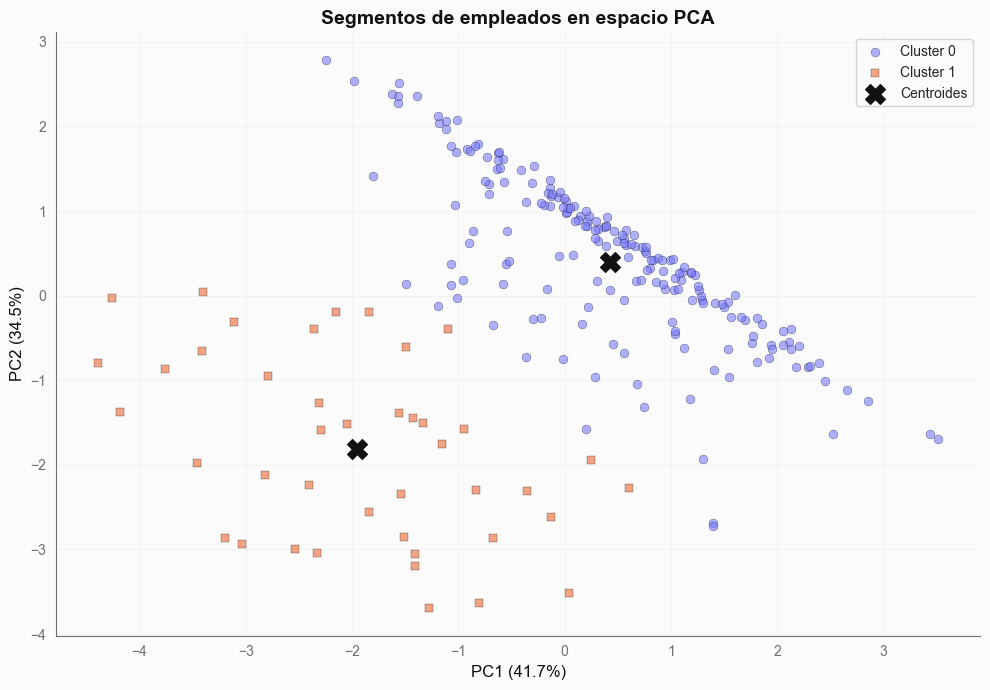

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for cl in range(best_k):
    mask = df_clean["Cluster"] == cl
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1], alpha=0.6, s=40,
               color=CLUSTER_PALETTE[cl], marker=CLUSTER_MARKERS[cl], label=f"Cluster {cl}",
               edgecolors="k", linewidths=0.3)

# Centroides
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], s=200, c=INK, marker="X",
           zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title("Segmentos de empleados en espacio PCA", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Perfil de rendimiento por cluster

Perfil medio de rendimiento por cluster:


,Sales_€K,Customers,Training_Hours,Satisfaction,Calls_per_day
Cluster,,,,,
0,75.9,34.9,9.9,97.4,29.2
1,71.8,32.3,10.6,75.9,9.5


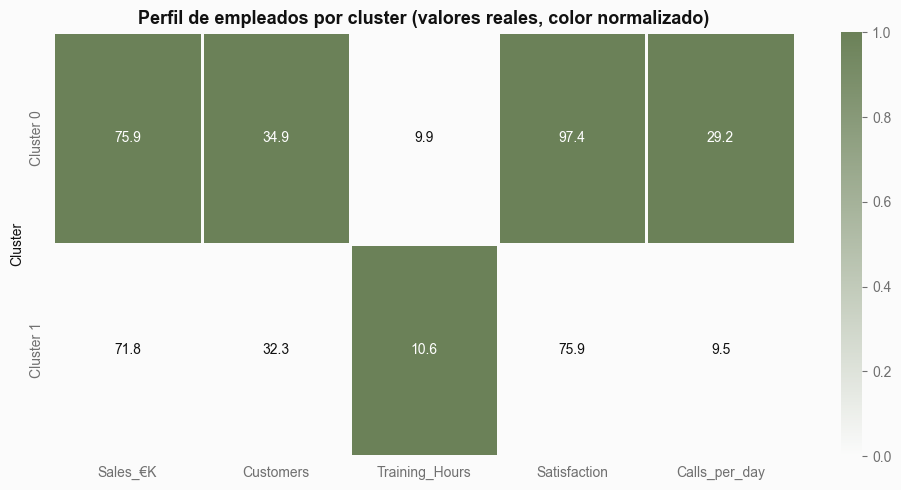

In [9]:
perfil = df_clean.groupby("Cluster")[num_cols].mean().round(1)
print("Perfil medio de rendimiento por cluster:")
display(perfil)

# Heatmap normalizado
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_norm, annot=perfil.values, fmt=".1f", cmap=SEQUENTIAL_GREEN,
            linewidths=2, linecolor=BACKGROUND, ax=ax,
            xticklabels=num_cols,
            yticklabels=[f"Cluster {i}" for i in range(best_k)])
color_annotations(ax, perfil_norm.values, threshold=0.65)
ax.set_title("Perfil de empleados por cluster (valores reales, color normalizado)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusiones y recomendaciones


Las 5 métricas de rendimiento se comprimen en **3 componentes que capturan el 95.4% de la varianza**. Cada componente tiene una lectura directa:

- **PC1 — Volumen comercial:** dominado por `Customers` (0.55) y `Sales_€K` (0.53). Mide la capacidad de generación de negocio del empleado.
- **PC2 — Actividad y satisfacción:** dominado por `Satisfaction` (0.55) y `Calls_per_day` (0.55). Captura el nivel de actividad diaria y la percepción del cliente sobre el servicio recibido.
- **PC3 — Formación:** dominado casi en exclusiva por `Training_Hours` (0.98). La formación es una dimensión independiente del rendimiento comercial y la actividad — los empleados que más se forman no son necesariamente los que más venden ni los que mejor satisfacción generan.

### K-Means — Segmentación

El silhouette de **0.4182 con k=2** indica una separación razonable entre los dos grupos. A diferencia del caso anterior (clientes, silhouette 0.27), aquí los clusters tienen una frontera más definida.

### Perfiles identificados

| Métrica | Cluster 0 (82%) | Cluster 1 (18%) | Diferencia clave |
|---|:---:|:---:|---|
| Sales_€K | 75.9 | 71.8 | Similar |
| Customers | 34.9 | 32.3 | Similar |
| Training_Hours | 9.9 | 10.6 | Similar |
| **Satisfaction** | **97.4** | **75.9** | **-22 puntos** |
| **Calls_per_day** | **29.2** | **9.5** | **-67%** |

La segmentación **no separa por rendimiento comercial** (ventas y clientes son casi idénticos). Lo que separa a los dos grupos es el **nivel de actividad y la satisfacción del cliente**:

- **Cluster 0 (82%) — Activos y bien valorados:** alta frecuencia de llamadas (29/día), satisfacción excelente (97.4). Son el estándar operativo de la empresa.
- **Cluster 1 (18%) — Bajo engagement, baja satisfacción:** apenas 9.5 llamadas/día (un tercio de sus compañeros), satisfacción de 75.9. Venden lo mismo pero con menor actividad y peor percepción del cliente.

### El hallazgo

Los empleados del Cluster 1 consiguen ventas similares con un tercio de las llamadas, pero su satisfacción de cliente es 22 puntos inferior. Esto sugiere un perfil que **cierra ventas pero no cuida la relación comercial** — lo que a medio plazo erosiona la retención de clientes y el valor de la cartera.

